# Nestor Addah
## K-Means Clustering Vs DBSCAN

# Section 1 — Data Loading, Exploration, and Preprocessing


In [ ]:
# Importing relevant libraries for loading, computing, manipulation, and visualization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [23]:
# loading the first datasets

df1 = pd.read_csv('/Users/nestoraddah/Downloads/mall_customers.csv')

# top 5 rows dataset
df1.head(5)

# shape of my dataset
df1.shape

# Basic Statistics 
df1.describe()

# checking for Datatypes and null values
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [37]:
# loading the second dataset
df2 = pd.read_csv('/Users/nestoraddah/Downloads/CC_GENERAL.csv')

# top 5 rows
df2.head(5)

# shape of dataset
df2.shape

# Basic statistics
df2.describe()

# checking for datatypes and null values 
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           500 non-null    object 
 1   BALANCE                           500 non-null    float64
 2   BALANCE_FREQUENCY                 500 non-null    float64
 3   PURCHASES                         500 non-null    float64
 4   ONEOFF_PURCHASES                  500 non-null    float64
 5   INSTALLMENTS_PURCHASES            500 non-null    float64
 6   CASH_ADVANCE                      500 non-null    float64
 7   PURCHASES_FREQUENCY               500 non-null    float64
 8   ONEOFF_PURCHASES_FREQUENCY        500 non-null    float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  500 non-null    float64
 10  CASH_ADVANCE_FREQUENCY            500 non-null    float64
 11  CASH_ADVANCE_TRX                  500 non-null    int64  
 12  PURCHASE

## 1.2 — Visualize the Raw Data 

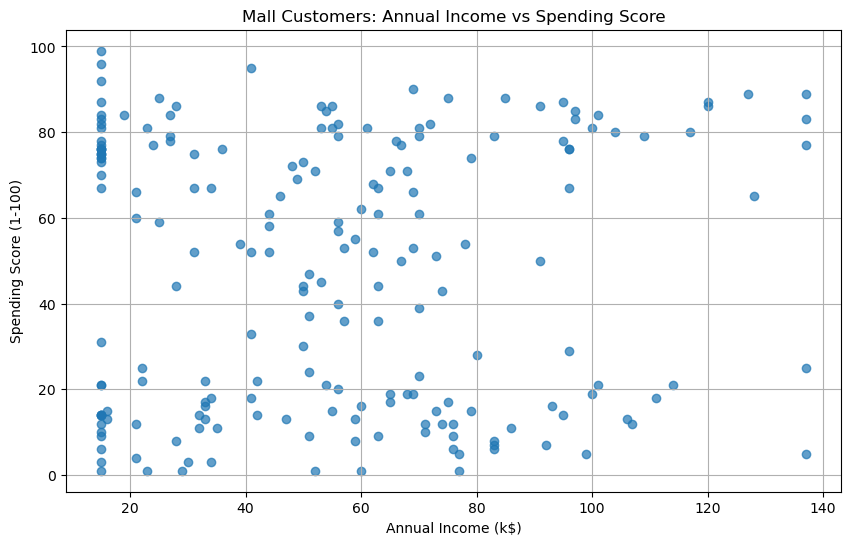

In [40]:
# Plot for Mall Customers with the 2 selected features
plt.figure(figsize=(10, 6))
plt.scatter(df1['Annual Income (k$)'], df1['Spending Score (1-100)'], alpha=0.7)
plt.title('Mall Customers: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

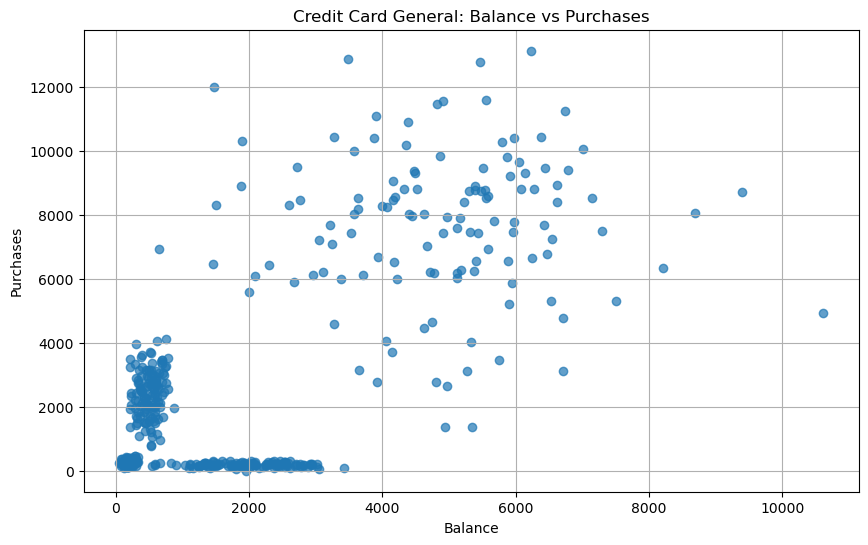

In [43]:
# Plot for Credit Card General with the 2 selected features 
plt.figure(figsize=(10, 6))
plt.scatter(df2['BALANCE'], df2['PURCHASES'], alpha=0.7)
plt.title('Credit Card General: Balance vs Purchases')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.grid(True)
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler


# 7Apply StandardScaler to the selected features

# Define the features for each dataset
features1 = ['Annual Income (k$)', 'Spending Score (1-100)']
features2 = ['BALANCE', 'PURCHASES']

# Initialize the scaler
scaler = StandardScaler()

# Calculate statistics BEFORE scaling for comparison
stats_before1 = df1[features1].agg(['mean', 'std']).T
stats_before1
stats_before2 = df2[features2].agg(['mean', 'std']).T
stats_before2

# Apply scaling to Mall Customers 
df1_scaled_values = scaler.fit_transform(df1[features1])
df1_scaled = pd.DataFrame(df1_scaled_values, columns=features1)

# Apply scaling to CC General 
df2_scaled_values = scaler.fit_transform(df2[features2])
df2_scaled = pd.DataFrame(df2_scaled_values, columns=features2)

# Show a before/after comparison of Mean and Standard Deviation

# Calculate statistics AFTER scaling
stats_after1 = df1_scaled.agg(['mean', 'std']).T
stats_after1
stats_after2 = df2_scaled.agg(['mean', 'std']).T
stats_after2

# Combine "Before" and "After" stats for Mall Customers
comparison1 = stats_before1.rename(columns={'mean': 'Mean (Before)', 'std': 'Std (Before)'}).join(
    stats_after1.rename(columns={'mean': 'Mean (After)', 'std': 'Std (After)'})
)

# Combine "Before" and "After" stats for CC General
comparison2 = stats_before2.rename(columns={'mean': 'Mean (Before)', 'std': 'Std (Before)'}).join(
    stats_after2.rename(columns={'mean': 'Mean (After)', 'std': 'Std (After)'})
)

# Final comparison table 
pd.concat([comparison1, comparison2], keys=['Mall Customers', 'Credit Card General'])

Mean (Before)  Std (Before)  \
Mall Customers      Annual Income (k$)           55.30500     32.267444   
                    Spending Score (1-100)       47.21500     30.863108   
Credit Card General BALANCE                    1889.59016   2048.801193   
                    PURCHASES                  2639.98854   3272.214259   

                                            Mean (After)  Std (After)  
Mall Customers      Annual Income (k$)      8.881784e-18     1.002509  
                    Spending Score (1-100) -1.165734e-16     1.002509  
Credit Card General BALANCE                -9.769963e-17     1.001002  
                    PURCHASES               3.375078e-17     1.001002

# Section 2 — K-Means: Varying k, Inertia, and Elbow Method

## 2.1 — Run K-Means for k = 2 to 10

In [53]:
from sklearn.cluster import KMeans

# Define the features and the range of k
k_range = range(2, 11)
results_mall = []
results_cc = []

# Prepare Scalers and scaled data
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(df1[['Annual Income (k$)', 'Spending Score (1-100)']])
X2_scaled = scaler.fit_transform(df2[['BALANCE', 'PURCHASES']].fillna(0))

# Train KMeans for each k and record inertia
for k in k_range:
    # Model for Mall Customers
    km_mall = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_mall.fit(X1_scaled)
    results_mall.append({'k': k, 'Inertia': km_mall.inertia_})
    
    # Model for Credit Card General
    km_cc = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_cc.fit(X2_scaled)
    results_cc.append({'k': k, 'Inertia': km_cc.inertia_})

# Format as a table for comparison
table_mall = pd.DataFrame(results_mall).set_index('k')
table_cc = pd.DataFrame(results_cc).set_index('k')

# Concatenate for a side-by-side view
inertia_table = pd.concat([table_mall, table_cc], axis=1, keys=['Mall Customers', 'Credit Card General'])
inertia_table

,Mall Customers,Credit Card General
,Inertia,Inertia
k,,
2,228.552284,249.339131
3,145.416782,179.156061
4,92.632988,134.874687
5,60.639405,104.435735
6,47.623693,77.470367
7,37.030407,64.500917
8,31.843666,54.887738
9,28.264308,46.747355


## 2.2 — Plot the Elbow Curve

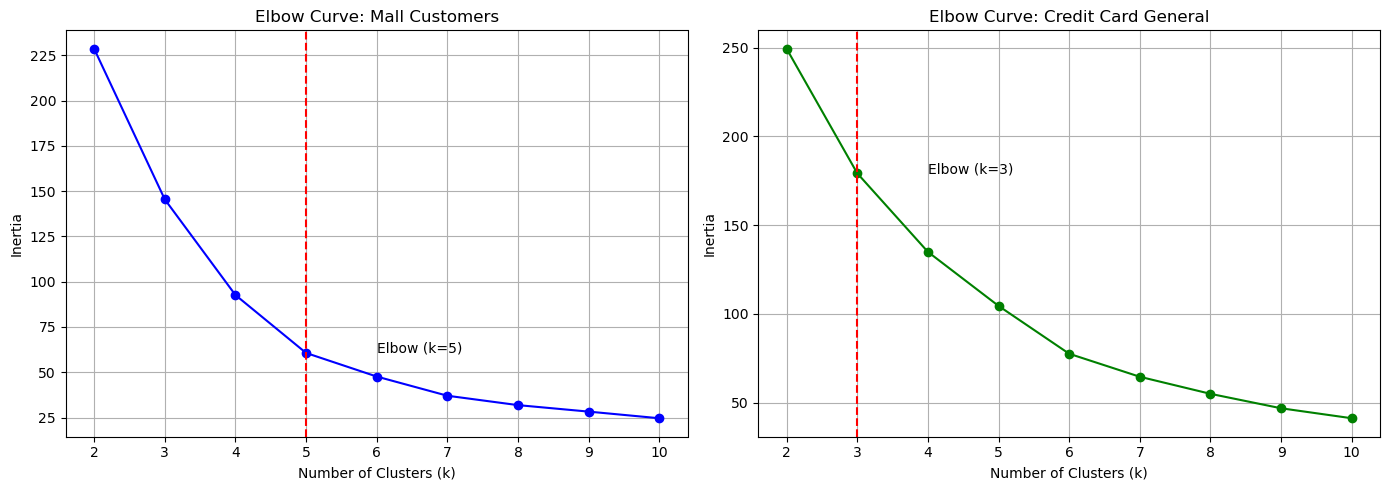

In [57]:
# Define configurations for each dataset: (Scaled Data, Title, Elbow k-value, Color)
configs = [
    (X1_scaled, 'Mall Customers', 5, 'b'),
    (X2_scaled, 'Credit Card General', 3, 'g')
]

plt.figure(figsize=(14, 5))

# Iterate through configurations to plot both curves
for i, (data, title, elbow, color) in enumerate(configs, 1):
    # Calculate inertia using list comprehension
    inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(data).inertia_ for k in range(2, 11)]
    
    # Create subplots
    plt.subplot(1, 2, i)
    plt.plot(range(2, 11), inertias, f'{color}o-')
    plt.axvline(x=elbow, color='r', linestyle='--')
    plt.annotate(f'Elbow (k={elbow})', (elbow, inertias[elbow-2]), xytext=(elbow+1, inertias[elbow-2]))
    
    # Labeling
    plt.title(f'Elbow Curve: {title}')
    plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia'); plt.grid(True)

plt.tight_layout()
plt.show()

## 2.3 — Visualize the Best K-Means Result

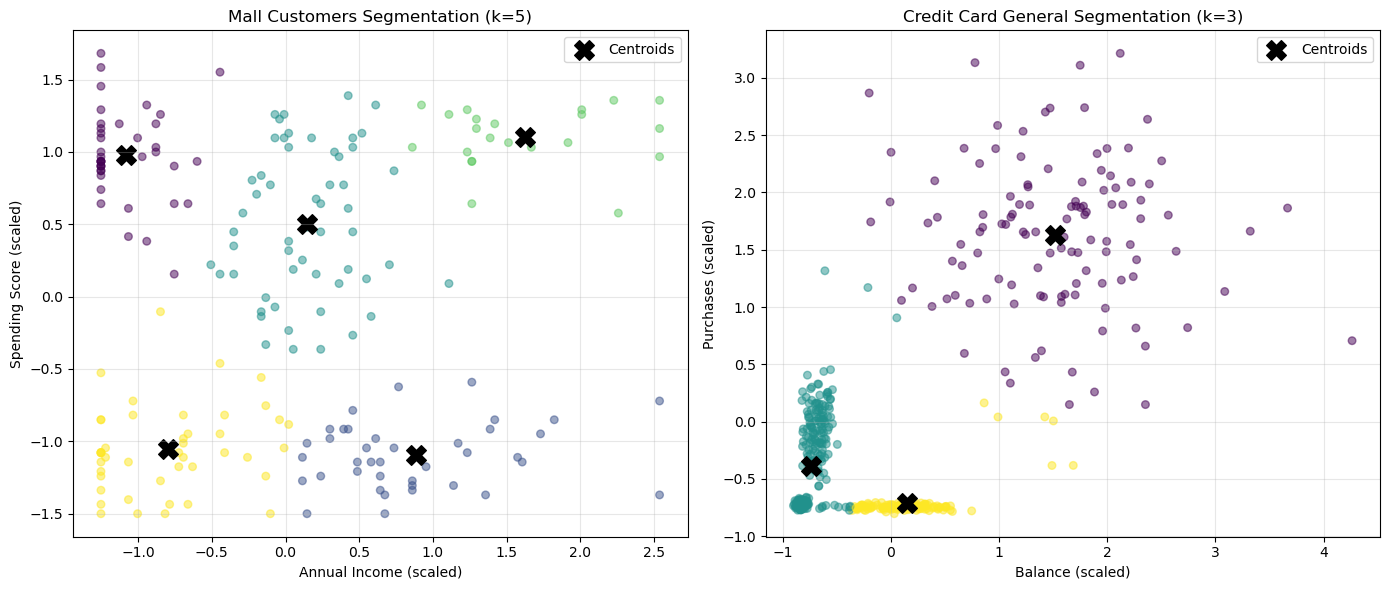

In [59]:
# Configuration: (Scaled Data, Optimal k, Name, [X-Label, Y-Label])
tasks = [
    (X1_scaled, 5, 'Mall Customers', ['Annual Income', 'Spending Score']),
    (X2_scaled, 3, 'Credit Card General', ['Balance', 'Purchases'])
]

plt.figure(figsize=(14, 6))

for i, (data, k, name, labels) in enumerate(tasks, 1):
    # 16. Train model with identified optimal k
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data)
    
    # 17-19. Plotting logic with centroids
    ax = plt.subplot(1, 2, i)
    ax.scatter(data[:, 0], data[:, 1], c=model.labels_, cmap='viridis', alpha=0.5, s=30)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], 
               s=200, c='black', marker='X', label='Centroids')
    
    # Efficiently set all titles and labels
    ax.set(title=f'{name} Segmentation (k={k})', 
           xlabel=f'{labels[0]} (scaled)', 
           ylabel=f'{labels[1]} (scaled)')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Section 3 — K-Means: Silhouette Score Analysis

## 3.1 — Compute Silhouette Scores for k = 2 to 10

In [66]:

from sklearn.metrics import silhouette_score


# Train K-Means and compute Silhouette Score & Inertia for k = 2 to 10
configs = [('Mall Customers', X1_scaled), ('Credit Card General', X2_scaled)]
results = []

for name, data in configs:
    for k in range(2, 11):
        model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data)
        results.append({
            'Dataset': name, 'k': k, 
            'Inertia': round(model.inertia_, 2), 
            'Silhouette': round(silhouette_score(data, model.labels_), 4)
        })

# Final comparison table
summary_df = pd.DataFrame(results).set_index(['Dataset', 'k'])
summary_df


Inertia  Silhouette
Dataset             k                      
Mall Customers      2    228.55      0.4216
                    3    145.42      0.4322
                    4     92.63      0.4550
                    5     60.64      0.5109
                    6     47.62      0.4945
                    7     37.03      0.5089
                    8     31.84      0.5080
                    9     28.26      0.4708
                    10    24.60      0.4594
Credit Card General 2    249.34      0.7148
                    3    179.16      0.5634
                    4    134.87      0.5212
                    5    104.44      0.5686
                    6     77.47      0.5975
                    7     64.50      0.5909
                    8     54.89      0.5980
                    9     46.75      0.6042
                    10    41.13      0.5936

## 3.2 — Plot Silhouette Scores

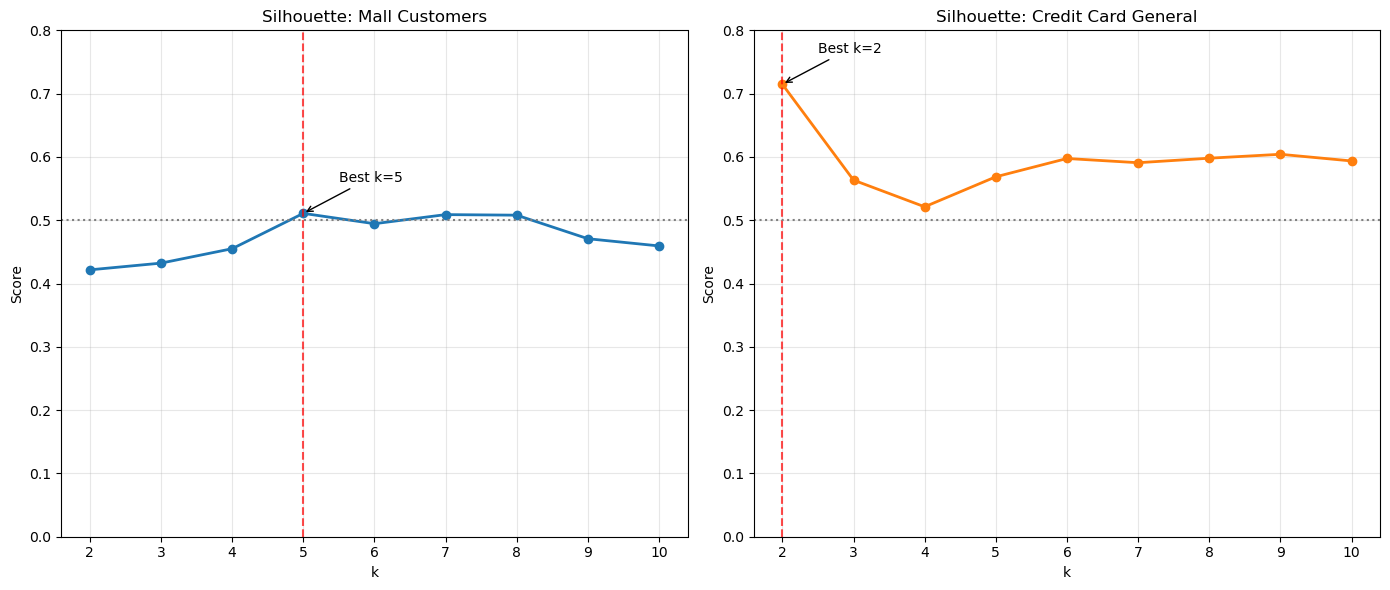

Inertia  Silhouette
Dataset             k                         
Mall Customers      2   228.552284    0.421622
                    3   145.416782    0.432232
                    4    92.632988    0.455022
                    5    60.639405    0.510850
                    6    47.623693    0.494508
                    7    37.030407    0.508871
                    8    31.843666    0.507992
                    9    28.264308    0.470782
                    10   24.596972    0.459394
Credit Card General 2   249.339131    0.714759
                    3   179.156061    0.563389
                    4   134.874687    0.521221
                    5   104.435735    0.568619
                    6    77.470367    0.597522
                    7    64.500917    0.590865
                    8    54.887738    0.597990
                    9    46.747355    0.604180
                    10   41.126045    0.593638

In [76]:
# Define configuration: (Data, Name, Color)
tasks = [(X1_scaled, 'Mall Customers', 'C0'), (X2_scaled, 'Credit Card General', 'C1')]
k_range, stats = range(2, 11), []

plt.figure(figsize=(14, 6))

for i, (data, name, color) in enumerate(tasks, 1):
    # 2. Compute models, scores, and inertia in one go using list comprehensions
    models = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(data) for k in k_range]
    scores = [silhouette_score(data, m.labels_) for m in models]
    
    # 3. Store results for the table
    for k, s, m in zip(k_range, scores, models):
        stats.append({'Dataset': name, 'k': k, 'Inertia': m.inertia_, 'Silhouette': s})
    
    # 4. Plotting logic
    ax = plt.subplot(1, 2, i)
    ax.plot(k_range, scores, marker='o', color=color, linewidth=2)
    
    # Mark best k, threshold, and labels
    best_k = k_range[scores.index(max(scores))]
    ax.axvline(best_k, ls='--', color='red', alpha=0.7)
    ax.axhline(0.5, ls=':', color='gray', label='Threshold (0.5)')
    ax.set(title=f'Silhouette: {name}', xlabel='k', ylabel='Score', ylim=(0, 0.8))
    ax.annotate(f'Best k={best_k}', (best_k, max(scores)), xytext=(best_k+0.5, max(scores)+0.05),
                arrowprops=dict(arrowstyle='->'))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show Table 
pd.DataFrame(stats).set_index(['Dataset', 'k'])

## 3.3 — Hard vs. Soft Clustering Analysis

In [78]:

from sklearn.metrics import silhouette_samples

# Task configuration (Data, Optimal k, Name)
tasks = [(X1_scaled, 5, 'Mall Customers'), (X2_scaled, 3, 'Credit Card General')]
results = []

for data, k, name in tasks:
    # Train the model and get distance matrix
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data)
    dist_matrix = model.transform(data) # 27. Distance to each centroid
    
    # Calculate silhouette samples to find lowest coefficients
    sil_scores = silhouette_samples(data, model.labels_)
    lowest_idx = np.argsort(sil_scores)[:5] # Bottom 5
    
    # Store results for table
    for i in lowest_idx:
        results.append({
            'Dataset': name, 'ID': i, 'Sil_Score': round(sil_scores[i], 4),
            'Assigned_K': model.labels_[i],
            **{f'Dist_to_C{c}': round(dist_matrix[i, c], 3) for c in range(k)}
        })

# Display the comparison table
pd.DataFrame(results).set_index(['Dataset', 'ID'])

Sil_Score  Assigned_K  Dist_to_C0  Dist_to_C1  \
Dataset             ID                                                   
Mall Customers      22      0.0204           4       2.167       0.888   
                    130     0.0247           2       1.726       2.438   
                    96      0.0336           2       2.364       1.210   
                    16      0.0556           4       2.293       0.895   
                    54      0.0571           4       1.111       1.997   
Credit Card General 342    -0.1103           1       3.061       0.524   
                    442    -0.1082           1       3.029       0.504   
                    450    -0.1024           1       3.037       0.506   
                    438    -0.0788           0       1.355       1.980   
                    327    -0.0557           0       1.328       1.726   

                         Dist_to_C2  Dist_to_C3  Dist_to_C4  
Dataset             ID                                       
Mall Customers      22        1.394       2.553       0.838  
                    130       0.945       1.038       2.766  
                    96        1.052       1.136       2.225  
                    16        1.559       2.700       0.789  
                    54        1.163       2.753       0.952  
Credit Card General 342       0.532         NaN         NaN  
                    442       0.522         NaN         NaN  
                    450       0.526         NaN         NaN  
                    438       1.422         NaN         NaN  
                    327       1.414         NaN         NaN

In [80]:

# 1. Define configurations (Data, Table Name)
configs = [(X1_scaled, "Dataset 1: Mall Customers"), (X2_scaled, "Dataset 2: Credit Card")]

for data, name in configs:
    rows = []
    for k in range(2, 11):
        # Train model and collect metrics
        model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data)
        rows.append({
            'k': k, 
            'Inertia': round(model.inertia_, 2), 
            'Silhouette Score': round(silhouette_score(data, model.labels_), 4)
        })
    
    # Create and display the table
    print(f"\n--- {name} ---")
    display(pd.DataFrame(rows).set_index('k'))


--- Dataset 1: Mall Customers ---


,Inertia,Silhouette Score
k,,
2,228.55,0.4216
3,145.42,0.4322
4,92.63,0.4550
5,60.64,0.5109
6,47.62,0.4945
7,37.03,0.5089
8,31.84,0.5080
9,28.26,0.4708
10,24.60,0.4594



--- Dataset 2: Credit Card ---


,Inertia,Silhouette Score
k,,
2,249.34,0.7148
3,179.16,0.5634
4,134.87,0.5212
5,104.44,0.5686
6,77.47,0.5975
7,64.50,0.5909
8,54.89,0.5980
9,46.75,0.6042
10,41.13,0.5936


# Section 4 — DBSCAN: Parameter Tuning and Results

## 4.1 — Baseline DBSCAN Run

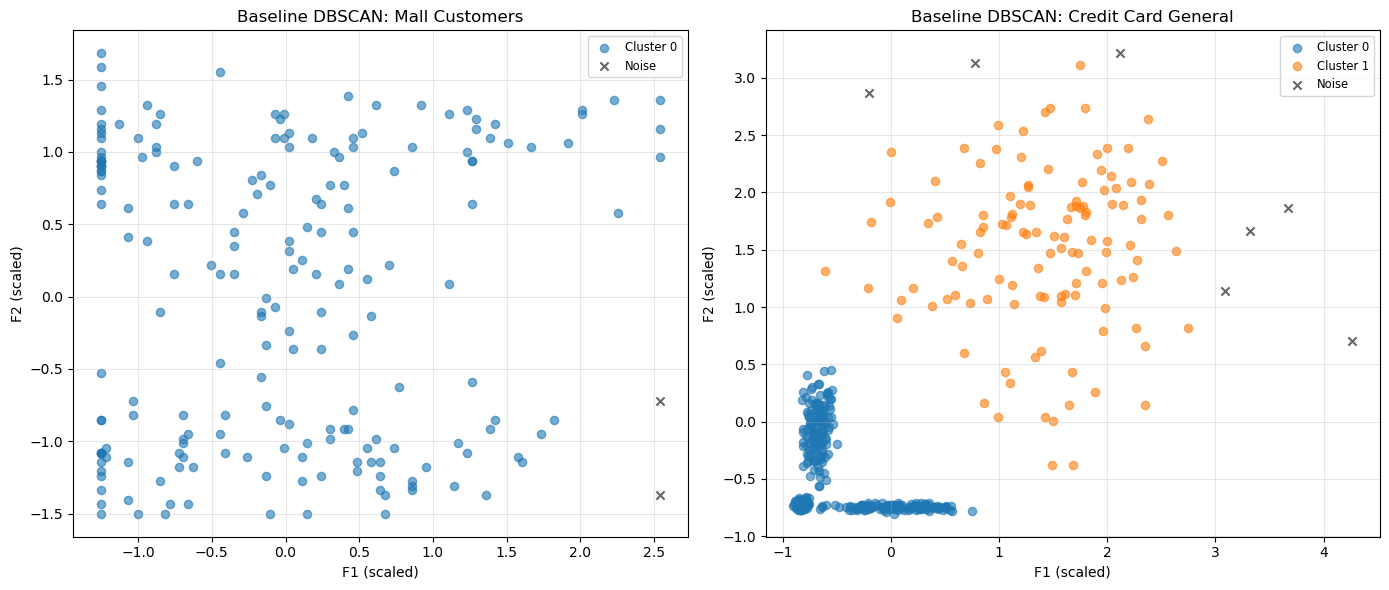

,Clusters,Noise,Sizes
Dataset,,,
Mall Customers,1,2,"{0: 198, -1: 2}"
Credit Card General,2,7,"{0: 375, 1: 118, -1: 7}"


In [84]:
from sklearn.cluster import DBSCAN

# Configuration: (Scaled Data, Dataset Name)
tasks = [
    (X1_scaled, 'Mall Customers'), 
    (X2_scaled, 'Credit Card General')
]

# Baseline stats storage
stats = []
plt.figure(figsize=(14, 6))

for i, (data, name) in enumerate(tasks, 1):
    #  Run DBSCAN (eps=0.5, min_samples=5)
    db = DBSCAN(eps=0.5, min_samples=5).fit(data)
    labels = db.labels_
    
    # Compute stats: clusters, noise points, and cluster sizes
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    stats.append({
        'Dataset': name, 'Clusters': n_clusters, 'Noise': n_noise, 
        'Sizes': pd.Series(labels).value_counts().to_dict()
    })
    
    #  Visualize results with black 'x' for noise
    ax = plt.subplot(1, 2, i)
    for k in set(labels):
        mask = (labels == k)
        ax.scatter(data[mask, 0], data[mask, 1], 
                   c='black' if k == -1 else None, 
                   marker='x' if k == -1 else 'o', 
                   s=35, alpha=0.6, label=f'Cluster {k}' if k != -1 else 'Noise')
    
    ax.set(title=f'Baseline DBSCAN: {name}', xlabel='F1 (scaled)', ylabel='F2 (scaled)')
    ax.legend(loc='best', fontsize='small'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final output table
pd.DataFrame(stats).set_index('Dataset')

## 4.2 — Systematic Parameter Grid Search

In [89]:
from itertools import product

#  Define the parameter grid
eps_values = [0.1, 0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 10, 15]
grid = list(product(eps_values, min_samples_values))

# Config (Assuming X1_scaled and X2_scaled are already prepared)
datasets = [(X1_scaled, 'Mall Customers'), (X2_scaled, 'Credit Card General')]
results = []

for data, name in datasets:
    for eps, min_samples in grid:
        #  Run DBSCAN and record metrics
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(data)
        labels = db.labels_
        
        # Calculate clusters (exclude noise -1) and noise count
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        
        # Calculate silhouette score (valid if clusters > 1, excluding noise points)
        score = -1 
        if n_clusters > 1:
            mask = labels != -1
            score = silhouette_score(data[mask], labels[mask])
        
        results.append({
            'Dataset': name, 'eps': eps, 'min_samples': min_samples,
            'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': round(score, 4)
        })

# Present results in a table sorted by silhouette score (descending)
results_df = pd.DataFrame(results)

# Create sorted subsets for Mall and CC General
mall_results = results_df[results_df['Dataset'] == 'Mall Customers'].sort_values('silhouette', ascending=False)
cc_results = results_df[results_df['Dataset'] == 'Credit Card General'].sort_values('silhouette', ascending=False)

# Display combined top results
pd.concat([mall_results.head(5), cc_results.head(5)])

,Dataset,eps,min_samples,n_clusters,n_noise,silhouette
1,Mall Customers,0.1,5,3,166,0.8798
7,Mall Customers,0.3,15,3,140,0.8574
6,Mall Customers,0.3,10,6,70,0.6574
0,Mall Customers,0.1,3,15,119,0.6543
11,Mall Customers,0.5,15,2,32,0.4915
26,Credit Card General,0.3,10,2,76,0.7938
31,Credit Card General,0.5,15,2,36,0.7610
30,Credit Card General,0.5,10,2,25,0.7481
23,Credit Card General,0.1,15,3,153,0.7305
29,Credit Card General,0.5,5,2,7,0.7156


## 4.3 — Visualize the Best DBSCAN Result

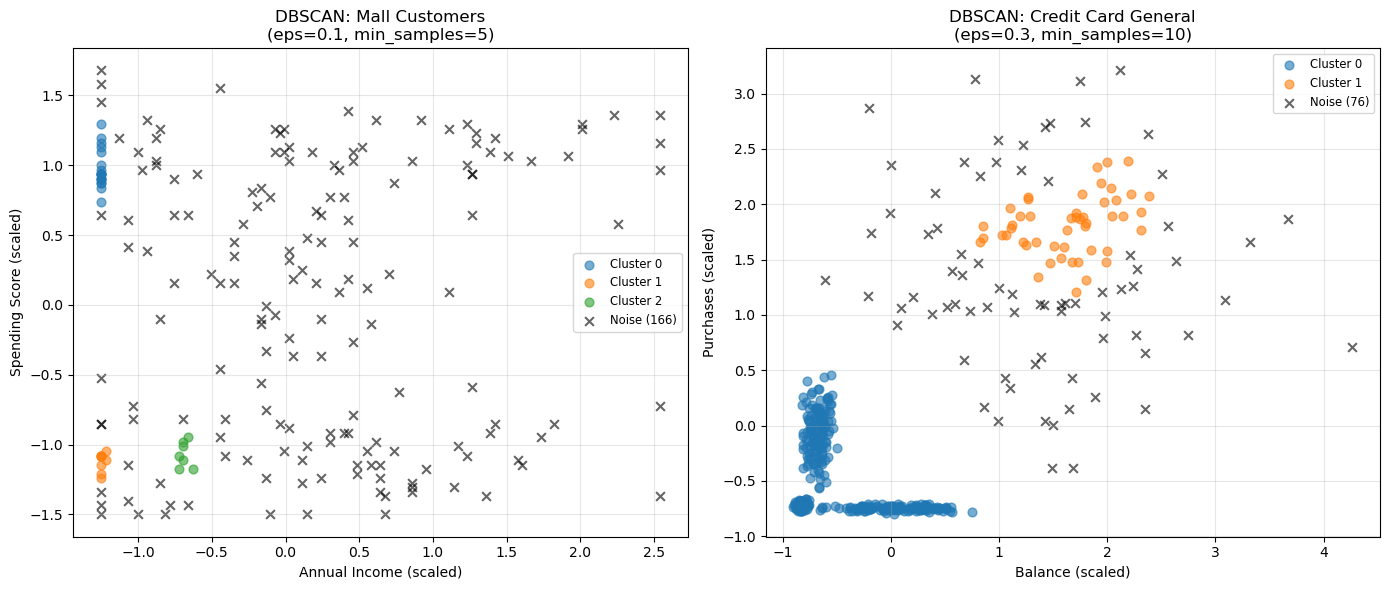

In [93]:
# Define the best parameter configurations for each dataset
best_configs = [
    (X1_scaled, 0.1, 5, 'Mall Customers', ['Annual Income', 'Spending Score']),
    (X2_scaled, 0.3, 10, 'Credit Card General', ['Balance', 'Purchases'])
]

plt.figure(figsize=(14, 6))

for i, (data, eps, min_s, name, labels) in enumerate(best_configs, 1):
    # Train DBSCAN with optimal parameters
    db = DBSCAN(eps=eps, min_samples=min_s).fit(data)
    y_db = db.labels_
    n_noise = (y_db == -1).sum()
    
    # Plotting with axis labels, title, and legend (including noise count)
    ax = plt.subplot(1, 2, i)
    for k in set(y_db):
        mask = (y_db == k)
        ax.scatter(data[mask, 0], data[mask, 1], 
                   c='black' if k == -1 else None, 
                   marker='x' if k == -1 else 'o', 
                   s=40, alpha=0.6, 
                   label=f'Cluster {k}' if k != -1 else f'Noise ({n_noise})')
    
    ax.set(title=f'DBSCAN: {name}\n(eps={eps}, min_samples={min_s})', 
           xlabel=f'{labels[0]} (scaled)', ylabel=f'{labels[1]} (scaled)')
    ax.legend(loc='best', fontsize='small'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Section 5 — Comparative Analysis: K-Means vs. DBSCAN

## 5.1 — Side-by-Side Visualization

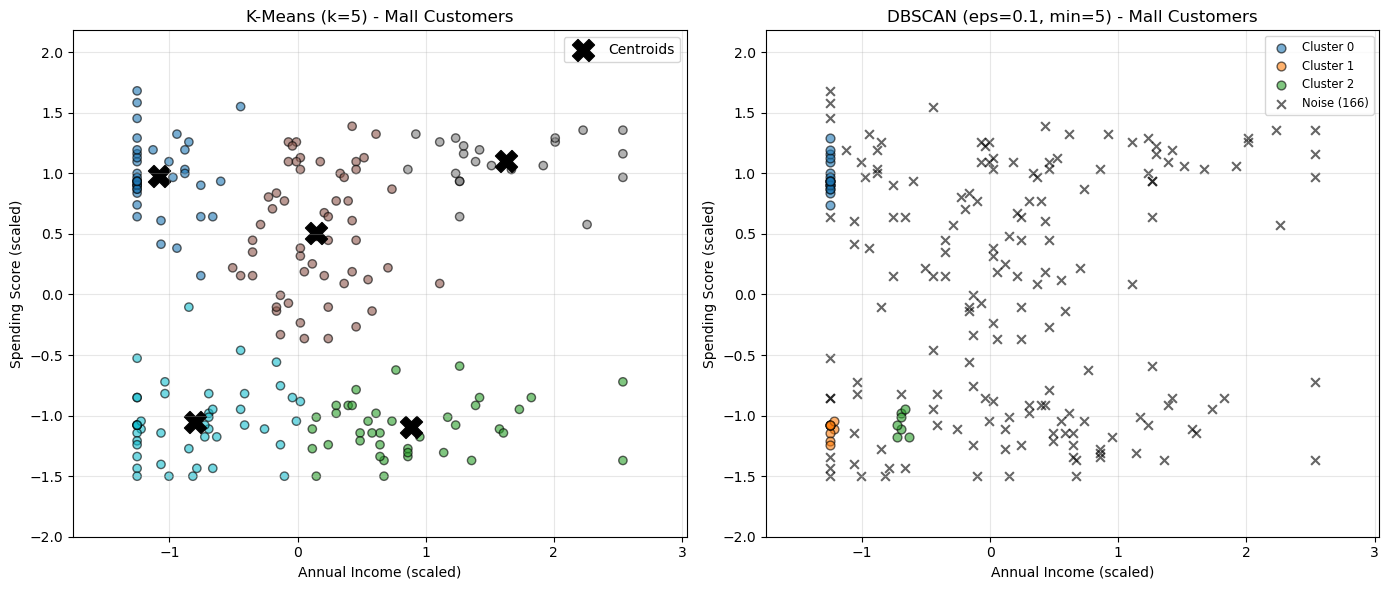

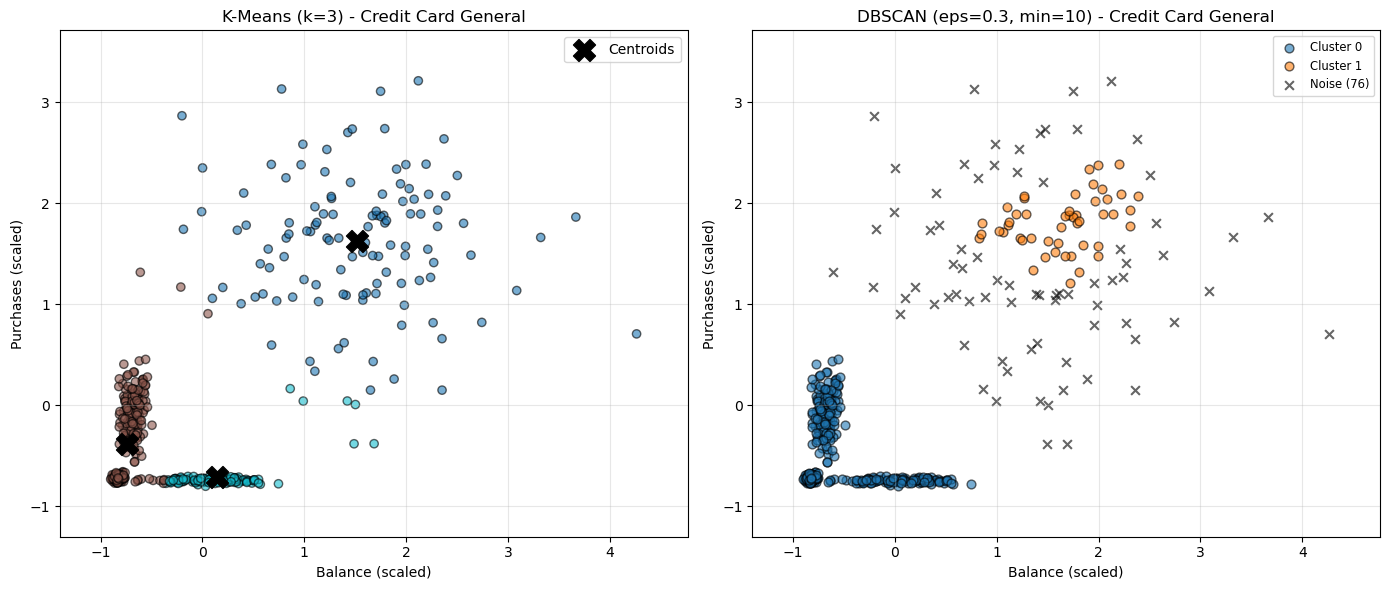

In [98]:

# Configuration for Side-by-Side plots
# (Scaled Data, K-Means k, DBSCAN eps, DBSCAN min, Dataset Name, Feature Labels)
configs = [
    (X1_scaled, 5, 0.1, 5, 'Mall Customers', ['Annual Income', 'Spending Score']),
    (X2_scaled, 3, 0.3, 10, 'Credit Card General', ['Balance', 'Purchases'])
]

for data, k_val, eps_val, min_val, name, lbls in configs:
    plt.figure(figsize=(14, 6))
    
    # Pre-train models
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10).fit(data)
    db = DBSCAN(eps=eps_val, min_samples=min_val).fit(data)
    
    # Consistent Axis Scales
    x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
    y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5

    # Left Subplot: K-Means
    plt.subplot(1, 2, 1)
    plt.scatter(data[:, 0], data[:, 1], c=km.labels_, cmap='tab10', alpha=0.6, edgecolors='k')
    plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=250, c='black', marker='X', label='Centroids')
    plt.title(f'K-Means (k={k_val}) - {name}')
    plt.xlabel(f'{lbls[0]} (scaled)'); plt.ylabel(f'{lbls[1]} (scaled)')
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max); plt.legend(); plt.grid(alpha=0.3)

    # Right Subplot: DBSCAN
    plt.subplot(1, 2, 2)
    labels = db.labels_
    for k in set(labels):
        mask = (labels == k)
        plt.scatter(data[mask, 0], data[mask, 1], 
                    c='black' if k == -1 else None, marker='x' if k == -1 else 'o', 
                    s=40, alpha=0.6, edgecolors='k' if k != -1 else None,
                    label=f'Cluster {k}' if k != -1 else f'Noise ({(labels == -1).sum()})')
    
    plt.title(f'DBSCAN (eps={eps_val}, min={min_val}) - {name}')
    plt.xlabel(f'{lbls[0]} (scaled)'); plt.ylabel(f'{lbls[1]} (scaled)')
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max); plt.legend(fontsize='small'); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5.2 — Algorithm Comparison Table 

In [102]:
# Define final optimized configurations (Data, KM_k, DB_eps, DB_min, Name)
final_configs = [
    (X1_scaled, 5, 0.1, 5, 'Mall Customers'),
    (X2_scaled, 3, 0.3, 10, 'Credit Card General')
]

for data, k_km, eps_db, min_db, name in final_configs:
    # Run K-Means (best k)
    km = KMeans(n_clusters=k_km, random_state=42, n_init=10).fit(data)
    km_sil = silhouette_score(data, km.labels_)
    
    # Run DBSCAN (best parameters)
    db = DBSCAN(eps=eps_db, min_samples=min_db).fit(data)
    db_labels = db.labels_
    n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    noise_db = (db_labels == -1).sum()
    db_sil = silhouette_score(data[db_labels != -1], db_labels[db_labels != -1]) if n_db > 1 else -1
    
    # Generate the Comparison Table
    df_comp = pd.DataFrame({
        'Criterion': ['Num Clusters', 'Silhouette (best)', 'Noise/Outliers', 'Sensitivity', 'Shape Assumption'],
        'K-Means': [k_km, round(km_sil, 4), 'N/A', 'Low (k)', 'Spherical'],
        'DBSCAN': [n_db, round(db_sil, 4), noise_db, 'High (eps/min)', 'Any shape']
    })
    
    print(f"\n--- 5.2 Comparison Table: {name} ---")
    display(df_comp)


--- 5.2 Comparison Table: Mall Customers ---


,Criterion,K-Means,DBSCAN
0,Num Clusters,5,3
1,Silhouette (best),0.5109,0.8798
2,Noise/Outliers,N/A,166
3,Sensitivity,Low (k),High (eps/min)
4,Shape Assumption,Spherical,Any shape



--- 5.2 Comparison Table: Credit Card General ---


,Criterion,K-Means,DBSCAN
0,Num Clusters,3,2
1,Silhouette (best),0.5634,0.7938
2,Noise/Outliers,N/A,76
3,Sensitivity,Low (k),High (eps/min)
4,Shape Assumption,Spherical,Any shape
